In [20]:
import pandas as pd
import numpy as np

# 1) Carregar o arquivo CSV que você me enviou
caminho_arquivo = "/content/2025_11_20_participacao_PIBIC-EM_v4.csv"
df = pd.read_csv(caminho_arquivo)

print("Dimensões da base original:", df.shape)
print("Níveis em tipo_ies_corrigido:", df["tipo_ies_corrigido"].unique())
print("Níveis em igc_categoria:", df["igc_categoria"].unique())

Dimensões da base original: (506, 43)
Níveis em tipo_ies_corrigido: ['IES Pública Federal' 'IES Privada' 'publica_municipal_outras'
 'IES Pública Estadual']
Níveis em igc_categoria: ['IGC Alto' 'IGC Médio']


In [21]:
# 2) Manter só quem tem IGC Alto ou Médio
df_igc = df[df["igc_categoria"].isin(["IGC Alto", "IGC Médio"])].copy()

# 3) Manter só IES (tirar institutos de pesquisa)
df_ies = df_igc[df_igc["tipo_ies_corrigido"] != "instituto_de_pesquisa"].copy()

print("Dimensões da base filtrada (IES com IGC):", df_ies.shape)

# Conferência rápida: devem aparecer 393 + 113 = 506
print("\nContagem de igc_categoria:")
print(df_ies["igc_categoria"].value_counts())

Dimensões da base filtrada (IES com IGC): (506, 43)

Contagem de igc_categoria:
igc_categoria
IGC Alto     393
IGC Médio    113
Name: count, dtype: int64


In [22]:
tabela = pd.crosstab(
    df_ies["tipo_ies_corrigido"],
    df_ies["igc_categoria"]
)

print("\nTabela de contingência (observados):")
print(tabela)
print("\nTotal geral:", tabela.to_numpy().sum())


Tabela de contingência (observados):
igc_categoria             IGC Alto  IGC Médio
tipo_ies_corrigido                           
IES Privada                     71         40
IES Pública Estadual            60         18
IES Pública Federal            256         47
publica_municipal_outras         6          8

Total geral: 506


In [23]:
tabela_pct_total = (tabela / tabela.to_numpy().sum()) * 100
print("\nPercentuais em relação ao total (%):")
print(tabela_pct_total.round(2))


Percentuais em relação ao total (%):
igc_categoria             IGC Alto  IGC Médio
tipo_ies_corrigido                           
IES Privada                  14.03       7.91
IES Pública Estadual         11.86       3.56
IES Pública Federal          50.59       9.29
publica_municipal_outras      1.19       1.58


Níveis em igc_categoria: ['IGC Alto' 'IGC Médio']
Níveis em tipo_ies_corrigido: ['IES Pública Federal' 'IES Privada' 'publica_municipal_outras'
 'IES Pública Estadual']

Percentuais em relação ao total (%):
igc_categoria             IGC Alto  IGC Médio
tipo_ies_corrigido                           
IES Privada                  14.03       7.91
IES Pública Estadual         11.86       3.56
IES Pública Federal          50.59       9.29
publica_municipal_outras      1.19       1.58

Gerando gráficos de IGC por tipo de instituição (apenas IES com IGC)...

 -> fig_IGC_tipoIES_PT_cinza.png


/tmp/ipython-input-4176388976.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")


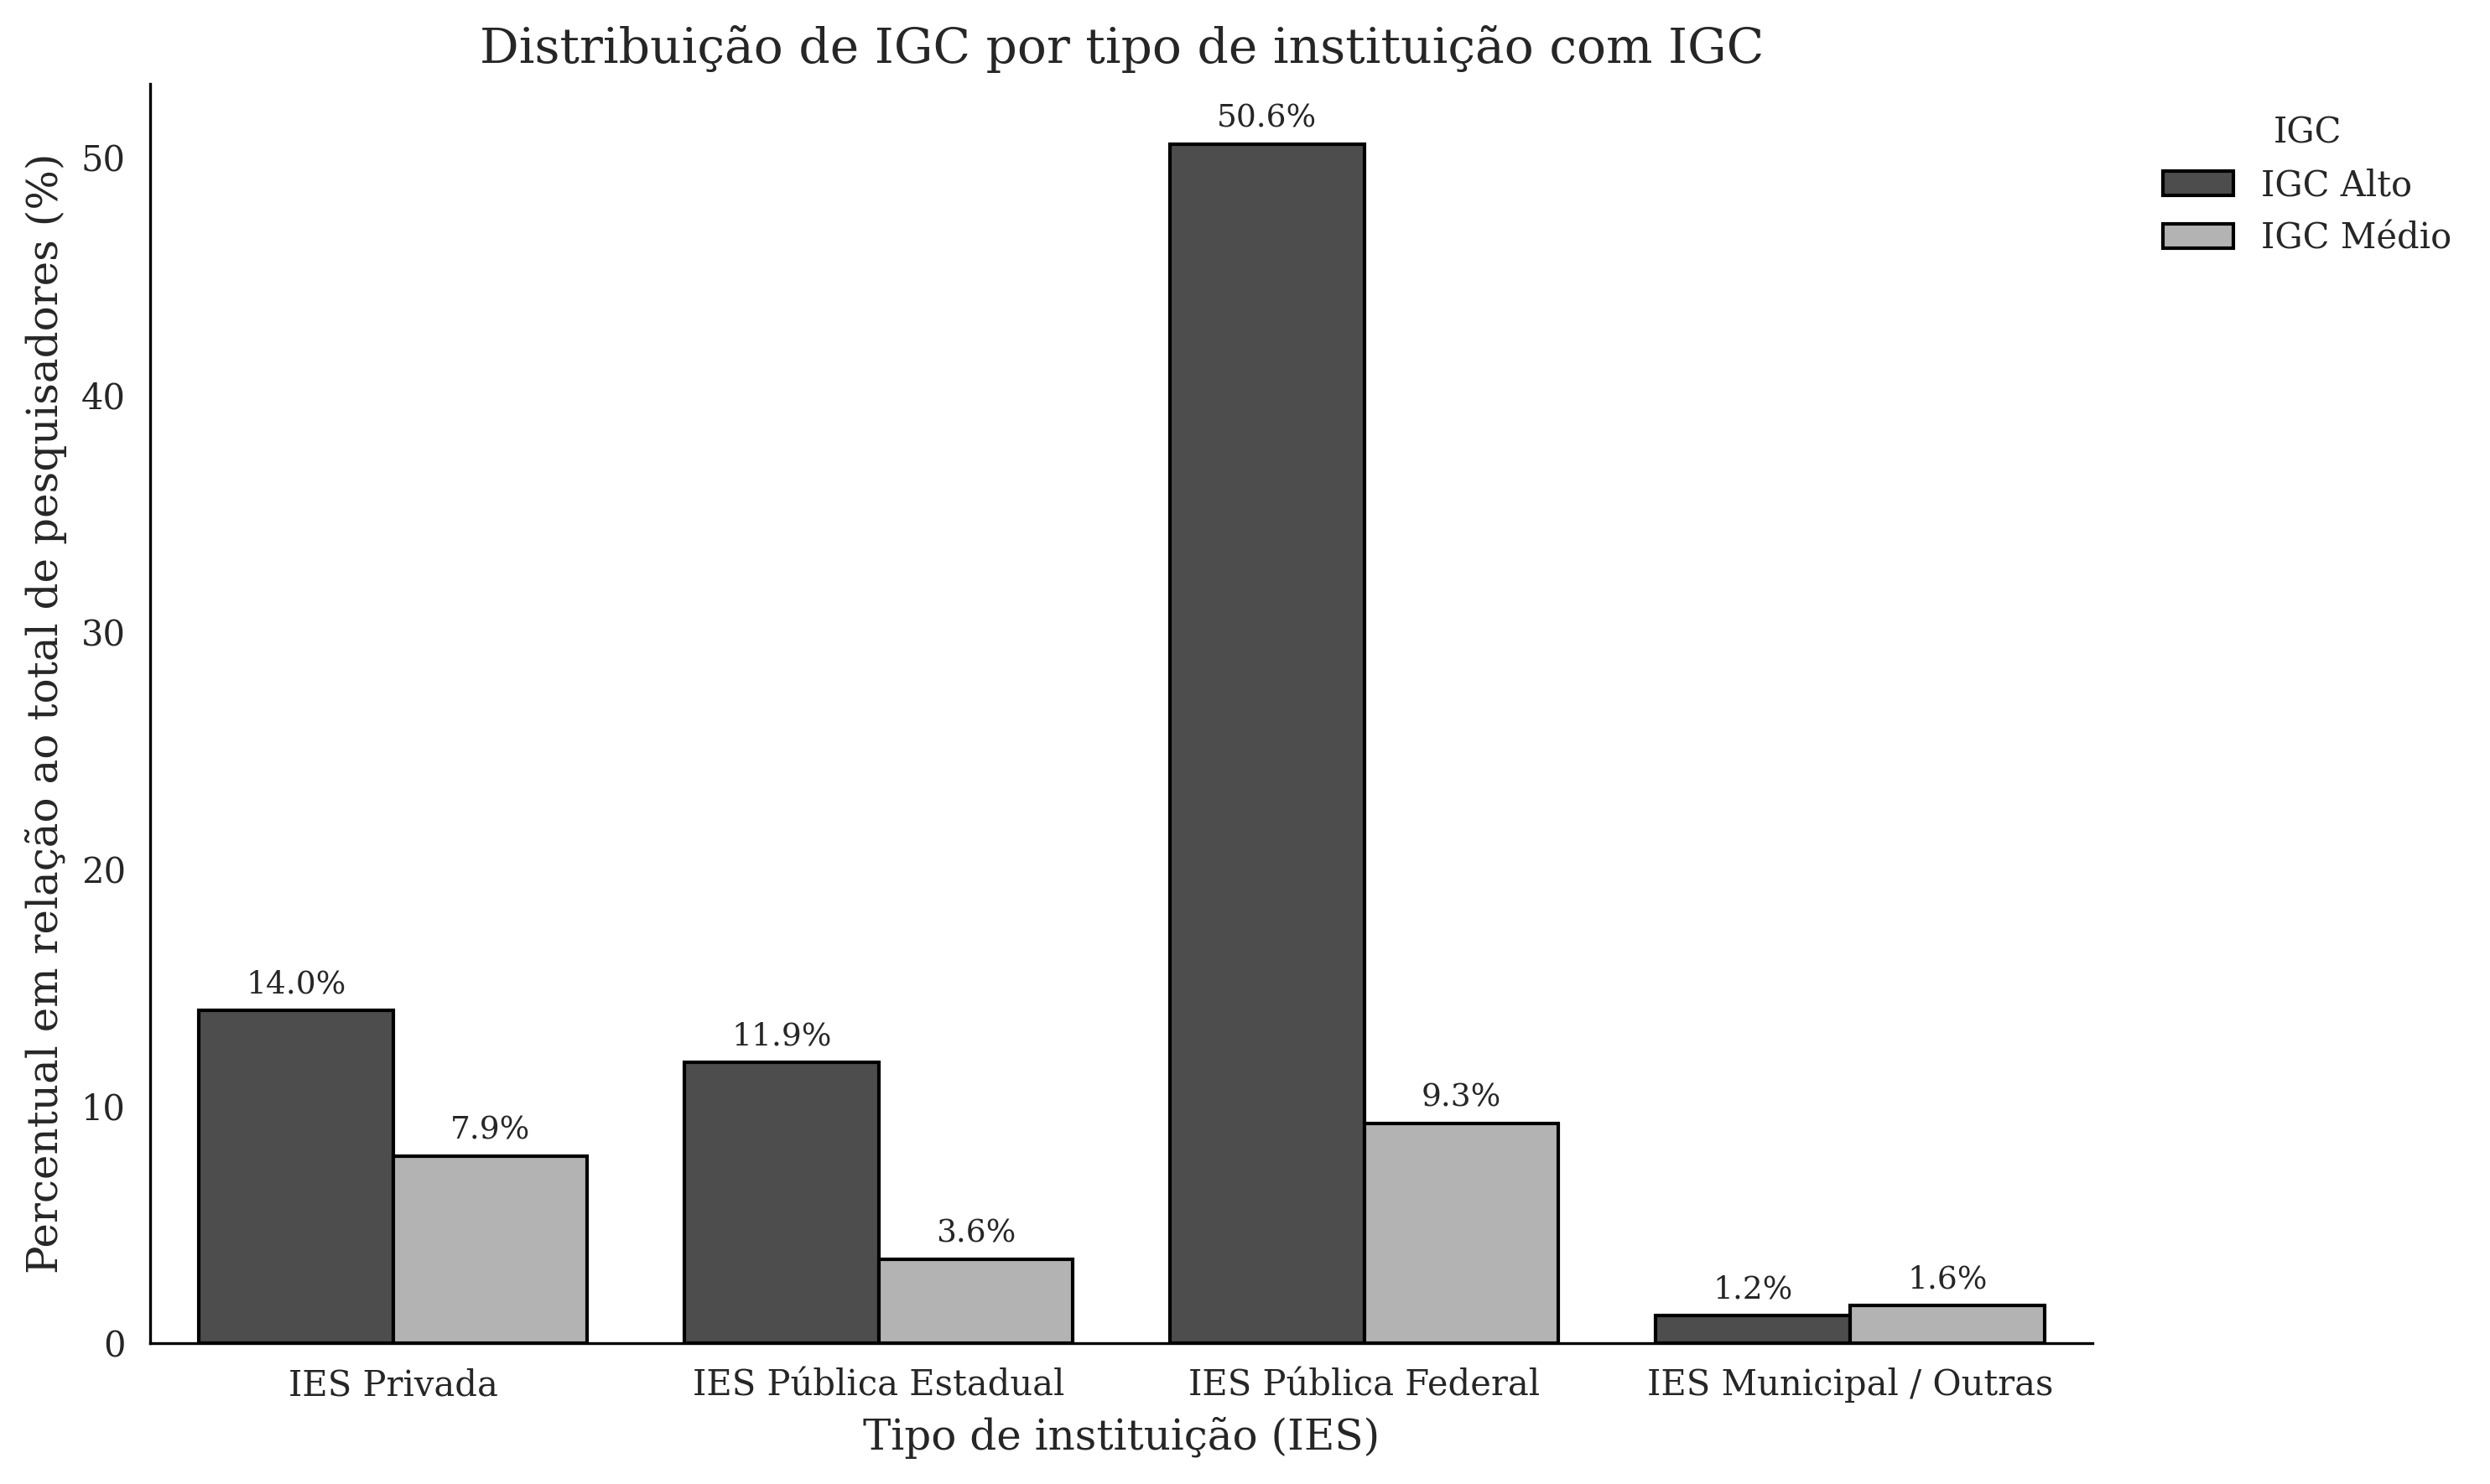

 -> fig_IGC_tipoIES_PT_color.png


/tmp/ipython-input-4176388976.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")


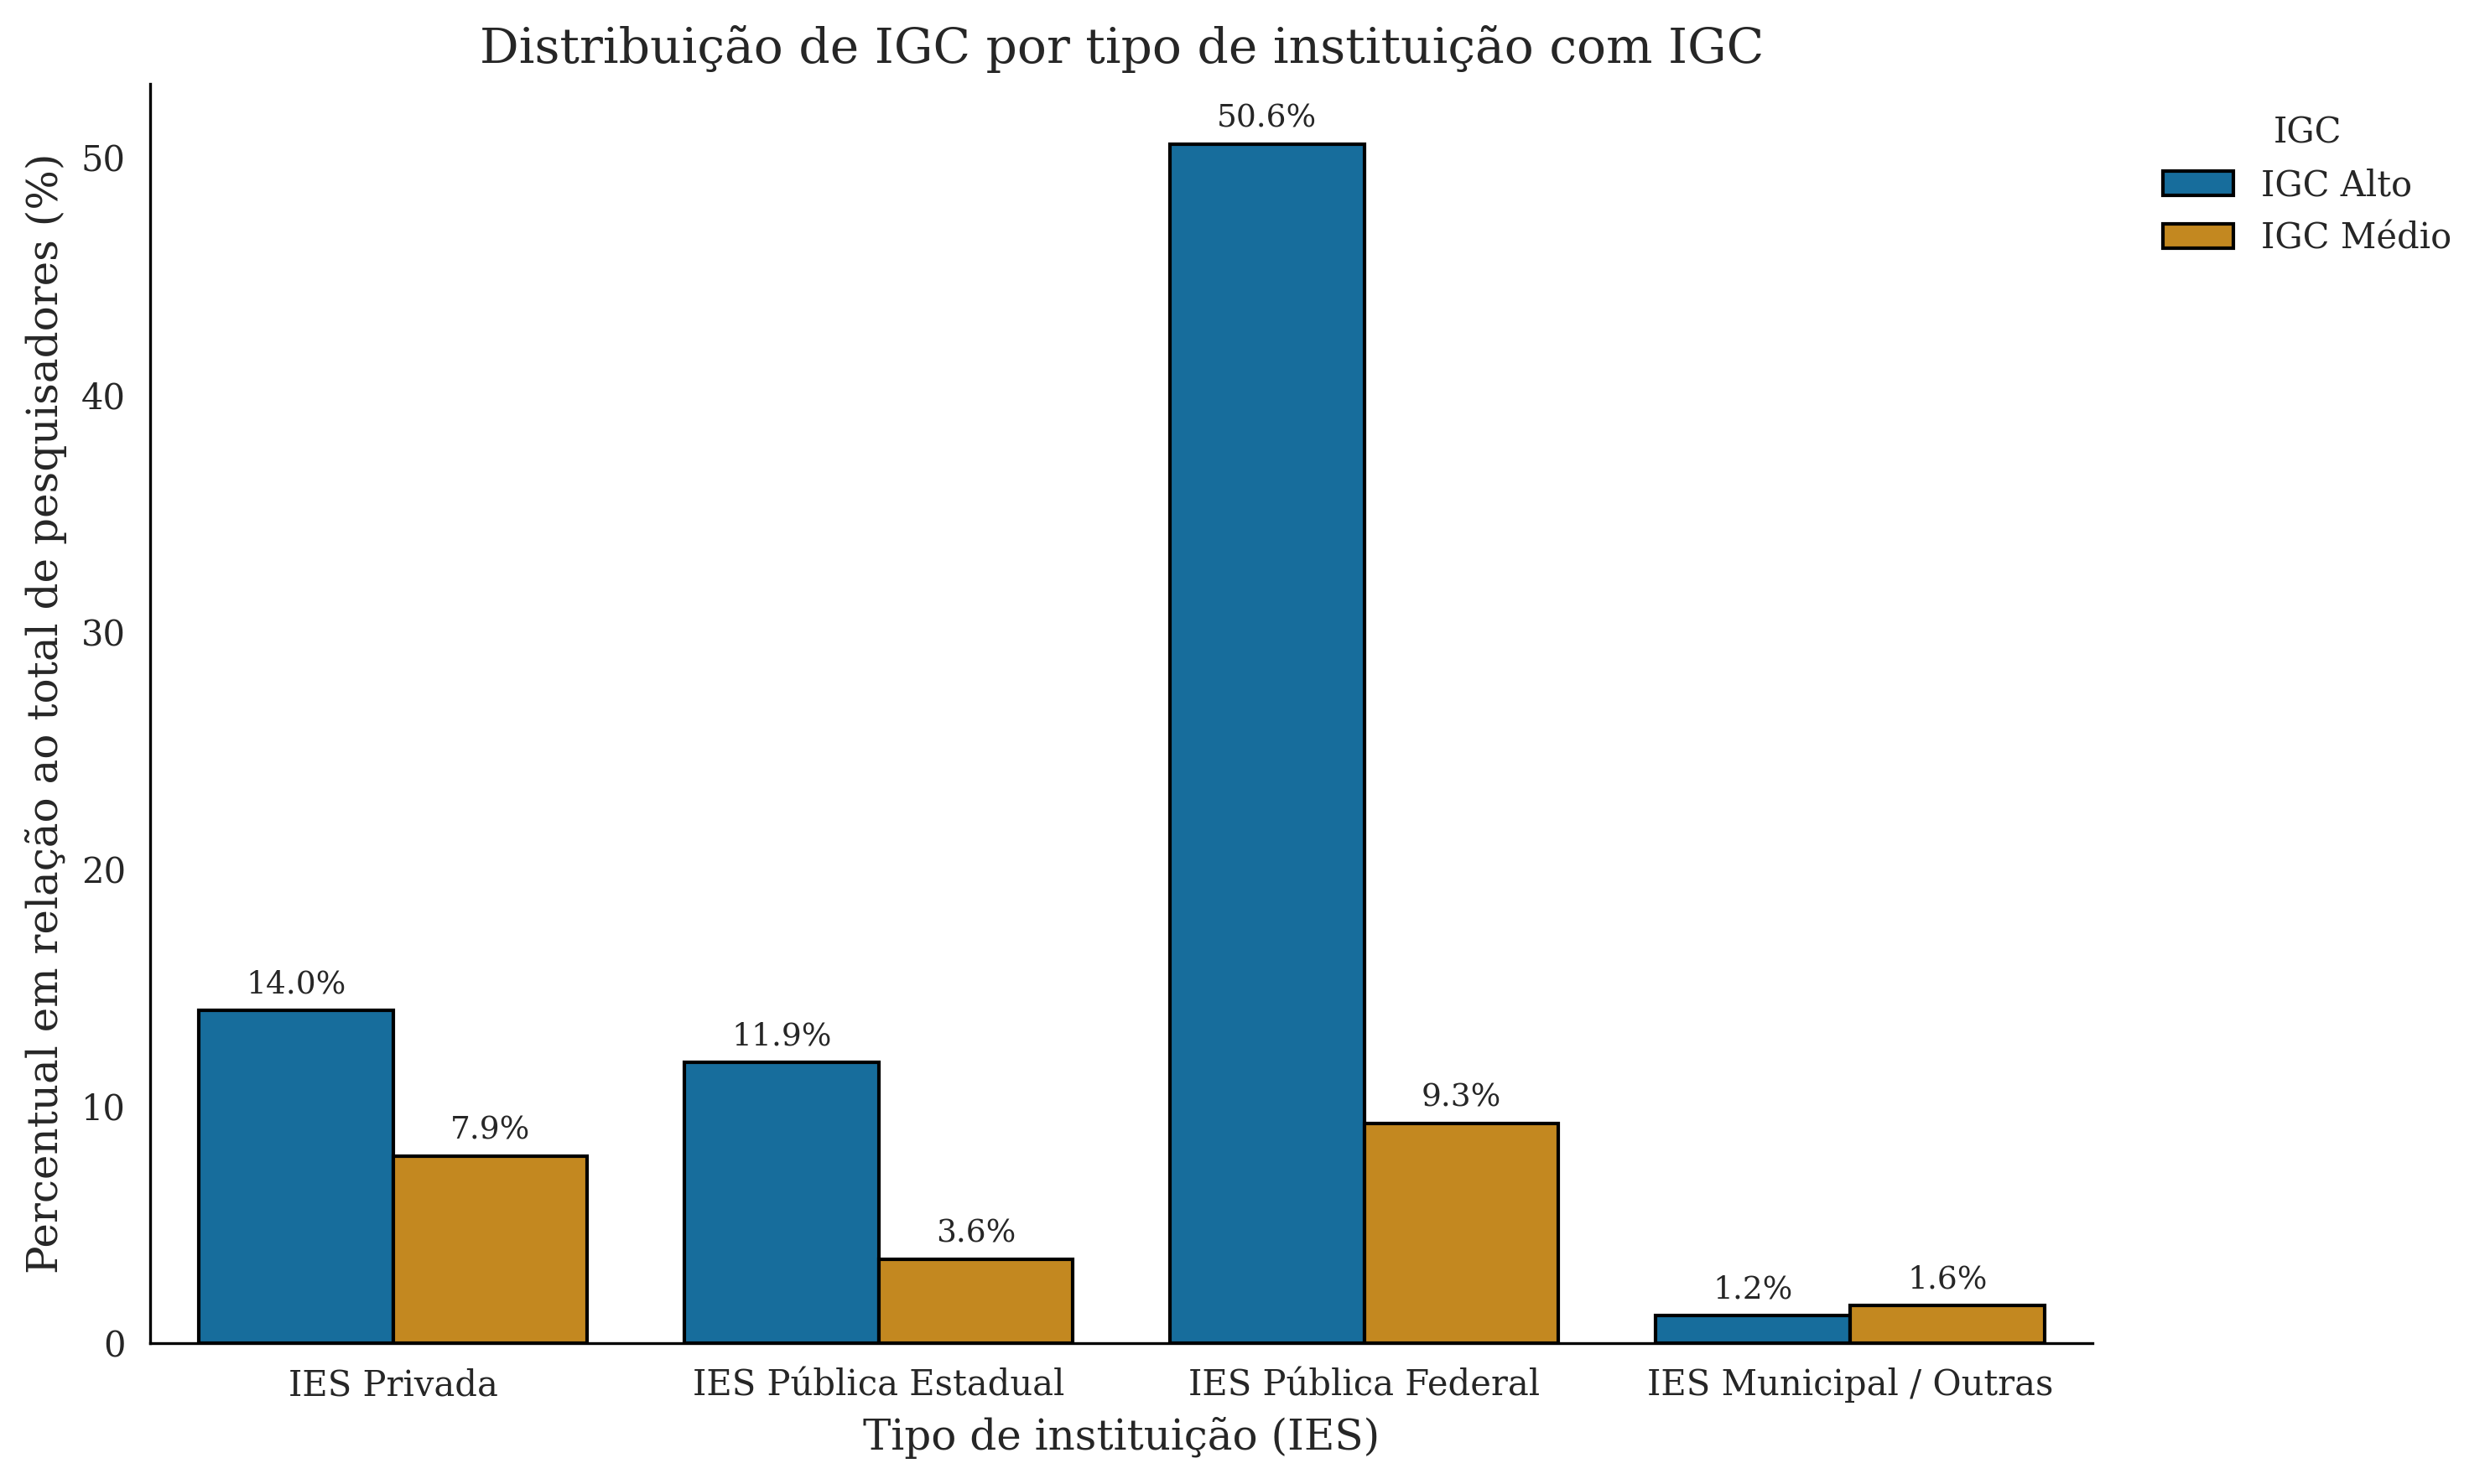

 -> fig_IGC_tipoIES_EN_gray.png


/tmp/ipython-input-4176388976.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")


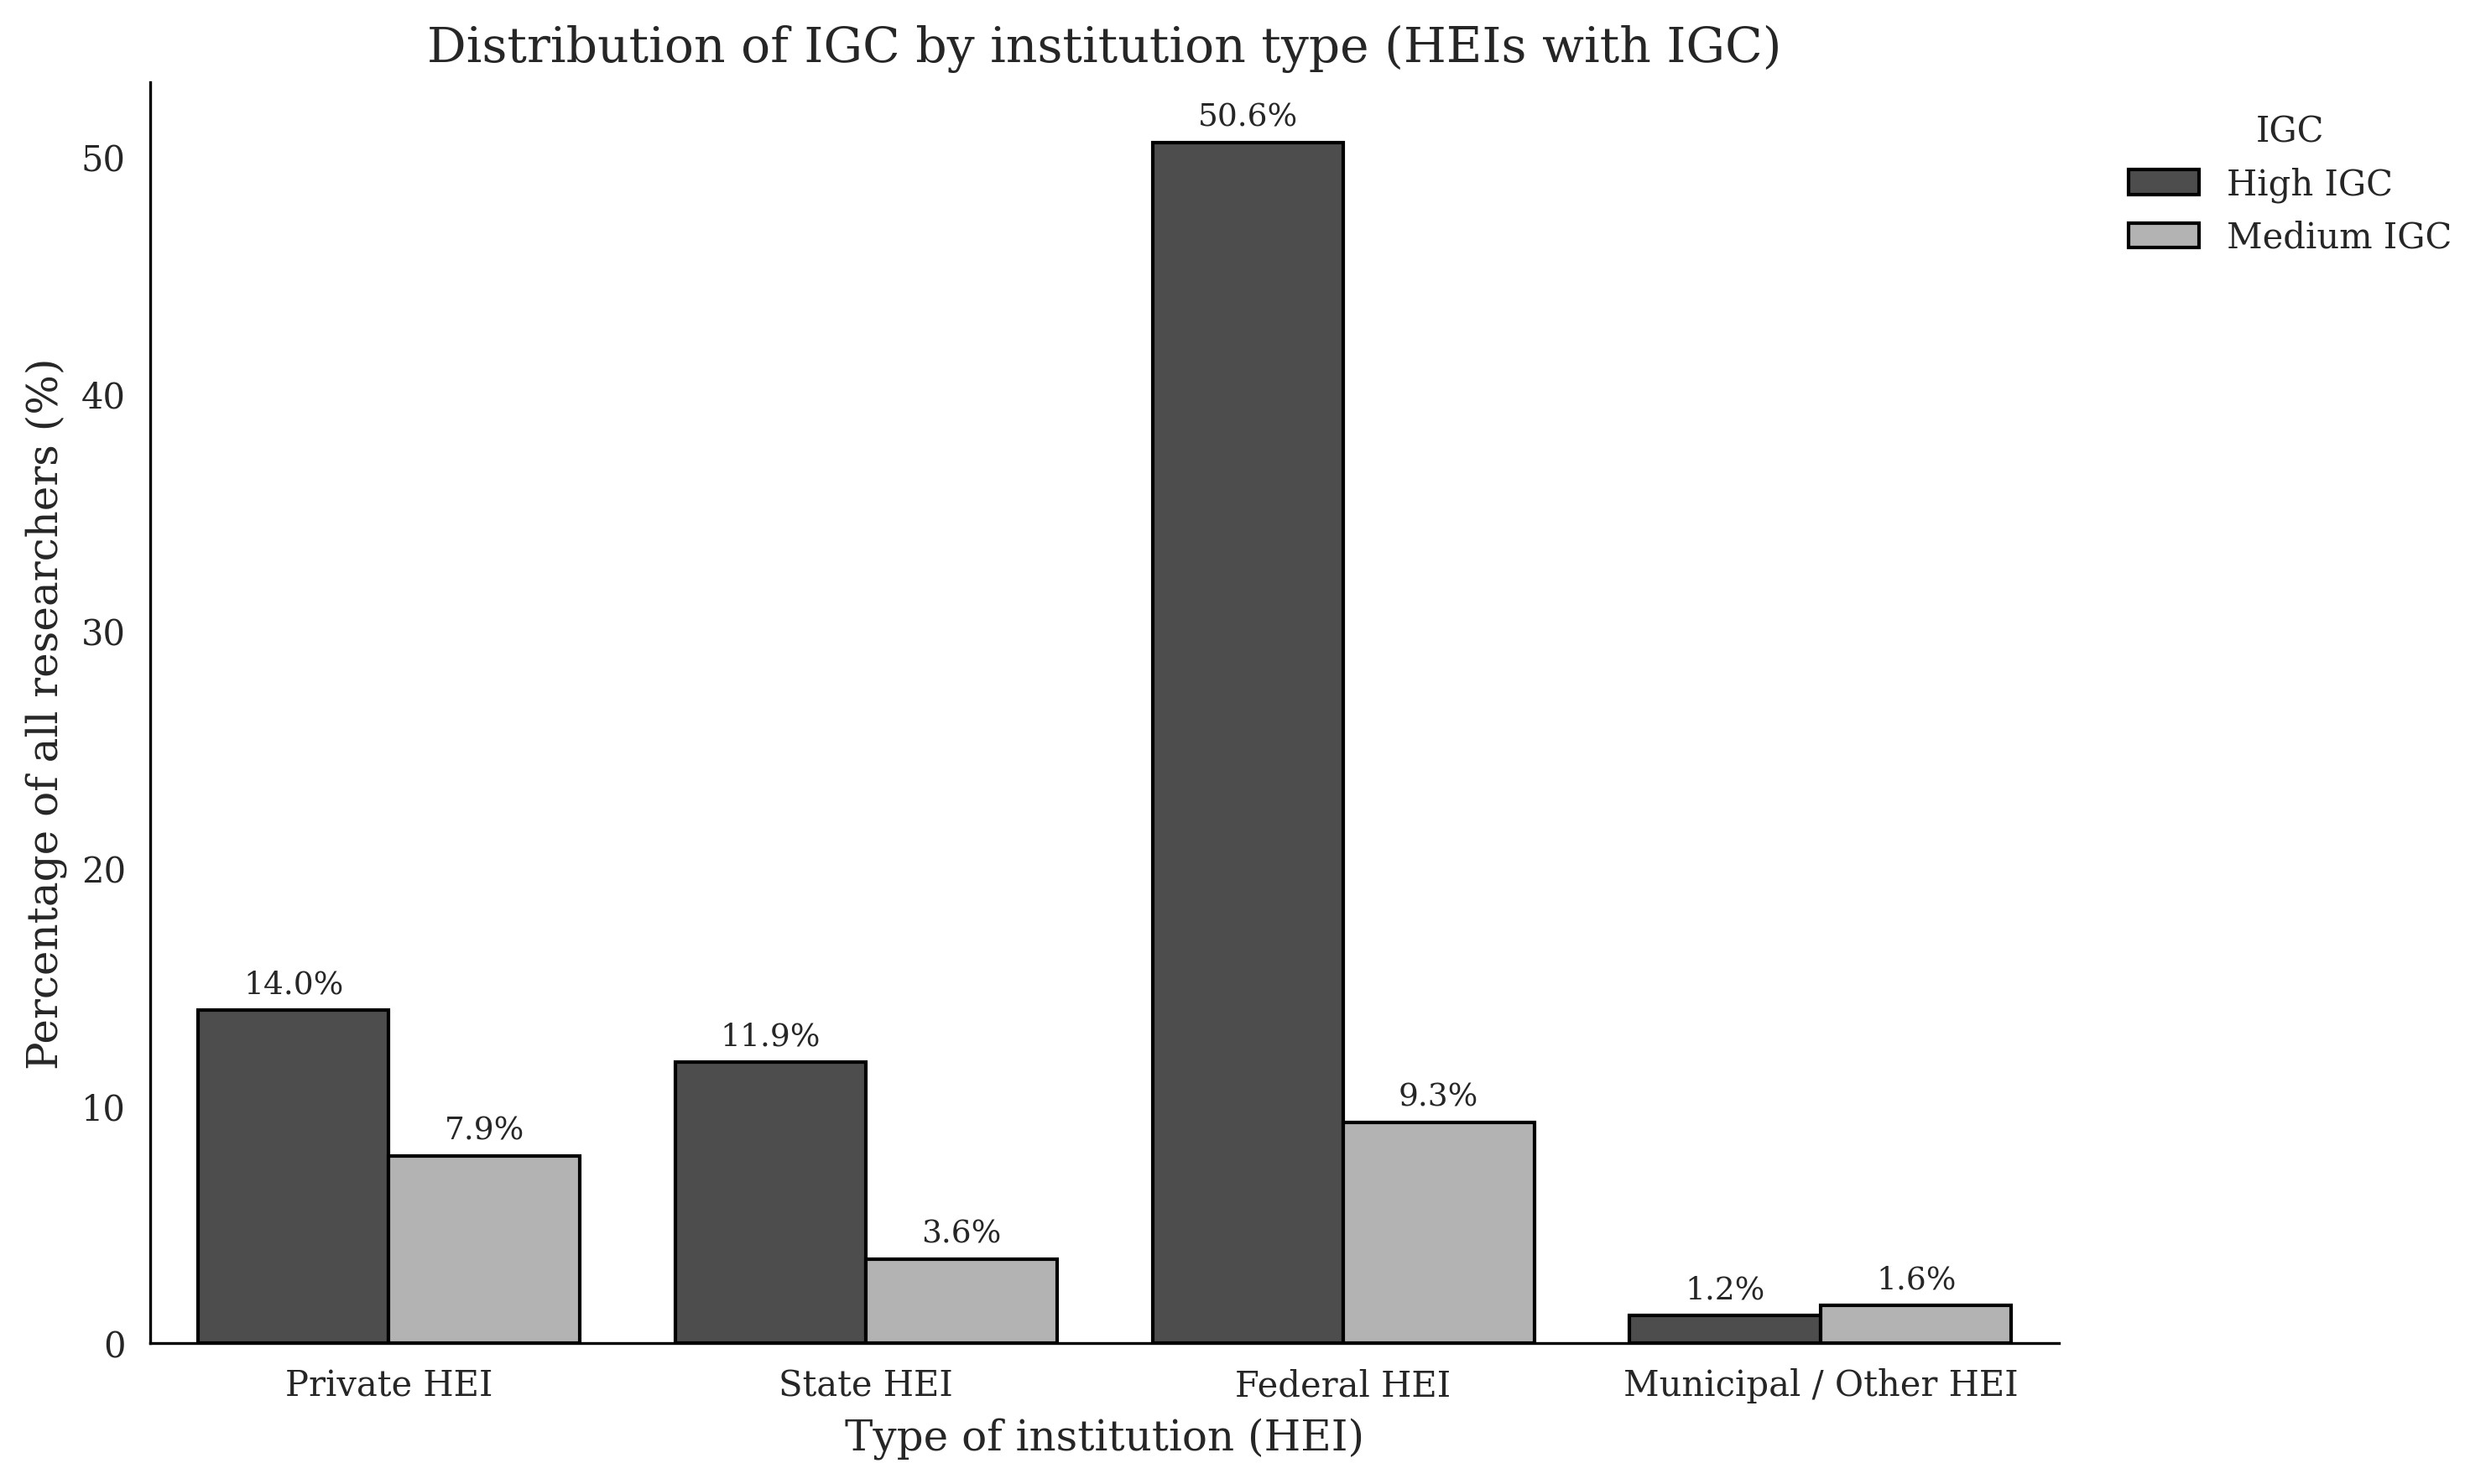

 -> fig_IGC_tipoIES_EN_color.png


/tmp/ipython-input-4176388976.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")


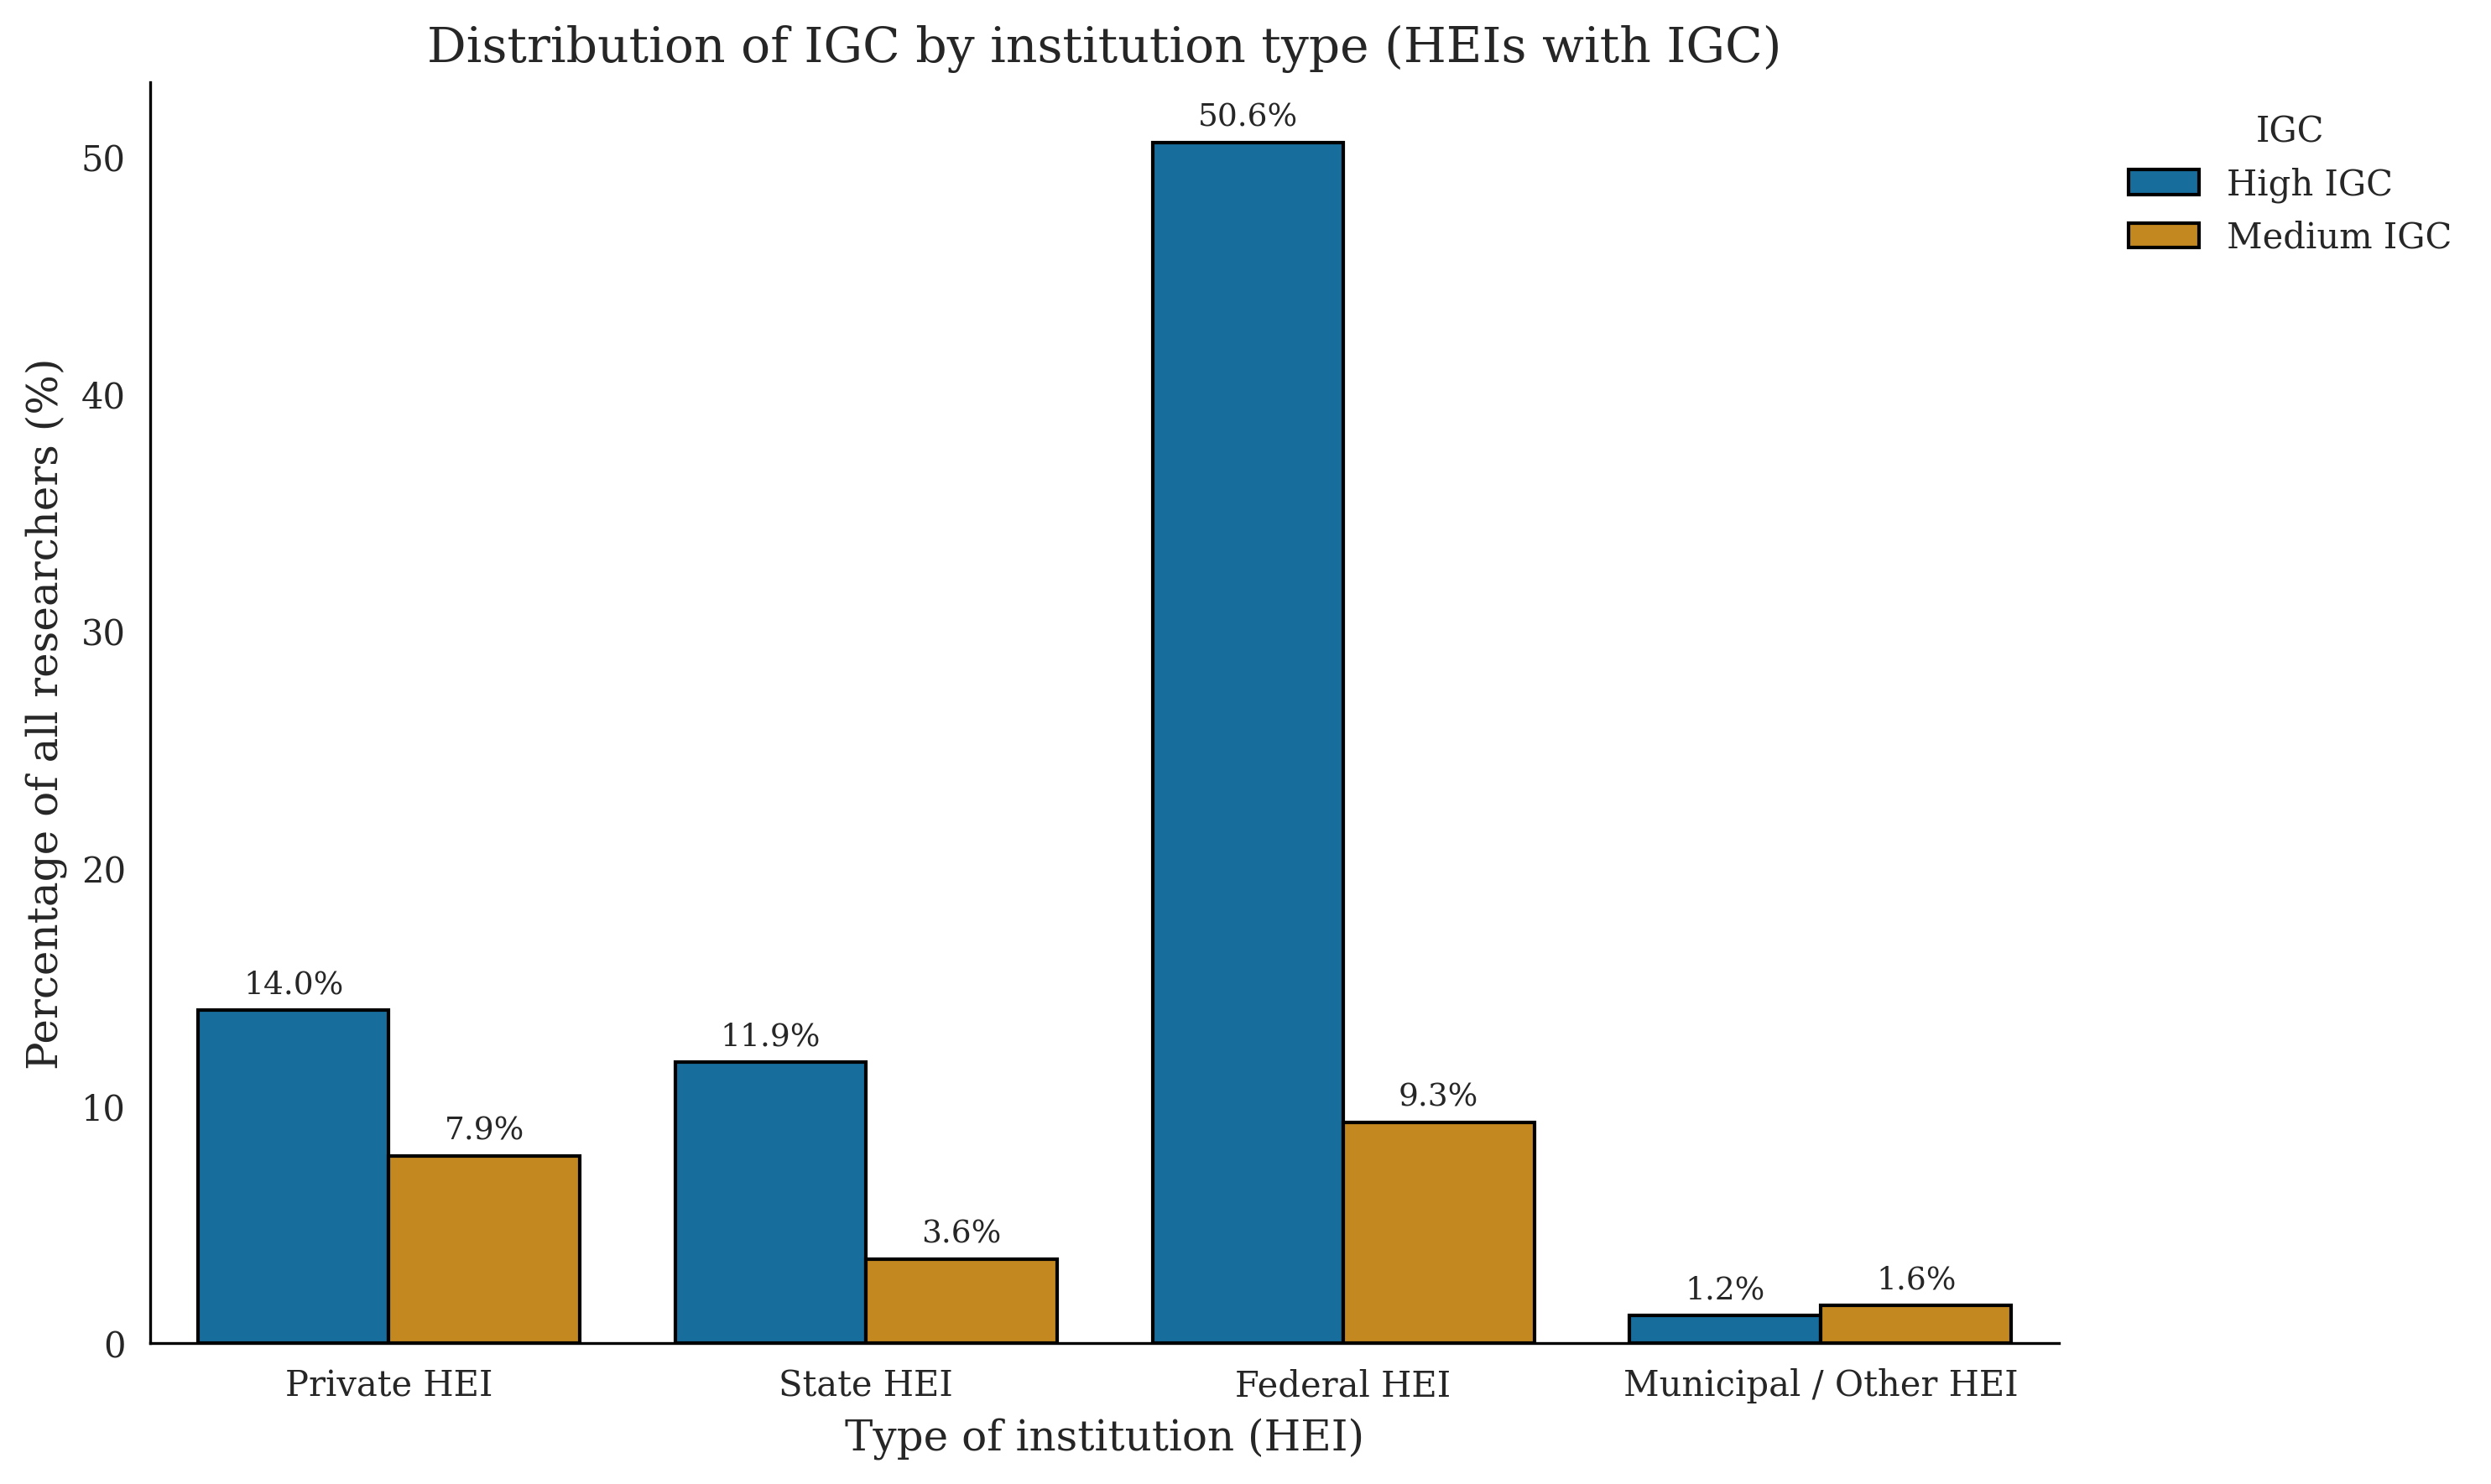


✔️ Todas as 4 versões foram geradas e salvas na pasta atual.



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ---------------------------------------------------------
# 1. Estilo APA (use em todos os gráficos)
# ---------------------------------------------------------
def estilo_apa():
    mpl.rcParams.update({
        # use uma fonte que existe no Colab
        "font.family": "DejaVu Serif",

        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 300,
    })

estilo_apa()

# ---------------------------------------------------------
# 2. Filtrar apenas instituições com IGC
#    (exclui "Sem IGC")
# ---------------------------------------------------------
base_ies_igc = df[df["igc_categoria"] != "Sem IGC"].copy()

print("Níveis em igc_categoria:", base_ies_igc["igc_categoria"].unique())
print("Níveis em tipo_ies_corrigido:", base_ies_igc["tipo_ies_corrigido"].unique())

# ---------------------------------------------------------
# 3. Tabela de contingência e percentuais em relação ao total
# ---------------------------------------------------------
tabela = pd.crosstab(
    base_ies_igc["tipo_ies_corrigido"],
    base_ies_igc["igc_categoria"]
)

tabela_pct_total = (tabela / tabela.to_numpy().sum()) * 100
print("\nPercentuais em relação ao total (%):")
print(tabela_pct_total.round(2))

# Colocar em formato "longo" para facilitar o uso no seaborn
pct_long = (
    tabela_pct_total
    .reset_index()
    .melt(id_vars="tipo_ies_corrigido",
          var_name="igc_categoria",
          value_name="pct_total")
)

# ---------------------------------------------------------
# 4. Mapas PT / EN para rótulos bonitos
# ---------------------------------------------------------
map_tipo_pt = {
    "IES Pública Federal":  "IES Pública Federal",
    "IES Pública Estadual": "IES Pública Estadual",
    "IES Privada":          "IES Privada",
    "publica_municipal_outras": "IES Municipal / Outras",
}

map_tipo_en = {
    "IES Pública Federal":  "Federal HEI",
    "IES Pública Estadual": "State HEI",
    "IES Privada":          "Private HEI",
    "publica_municipal_outras": "Municipal / Other HEI",
}

map_igc_pt = {
    "IGC Alto":   "IGC Alto",
    "IGC Médio":  "IGC Médio",
}

map_igc_en = {
    "IGC Alto":   "High IGC",
    "IGC Médio":  "Medium IGC",
}

pct_long["tipo_pt"] = pct_long["tipo_ies_corrigido"].map(map_tipo_pt)
pct_long["tipo_en"] = pct_long["tipo_ies_corrigido"].map(map_tipo_en)
pct_long["igc_pt"]  = pct_long["igc_categoria"].map(map_igc_pt)
pct_long["igc_en"]  = pct_long["igc_categoria"].map(map_igc_en)

# ---------------------------------------------------------
# 5. Função para gerar gráfico com rótulos
# ---------------------------------------------------------
def grafico_igc_pct(idioma="pt", palette="gray"):
    estilo_apa()

    if idioma == "pt":
        x_col   = "tipo_pt"
        hue_col = "igc_pt"
        xlabel  = "Tipo de instituição (IES)"
        ylabel  = "Percentual em relação ao total de pesquisadores (%)"
        titulo  = "Distribuição de IGC por tipo de instituição com IGC"
    else:
        x_col   = "tipo_en"
        hue_col = "igc_en"
        xlabel  = "Type of institution (HEI)"
        ylabel  = "Percentage of all researchers (%)"
        titulo  = "Distribution of IGC by institution type (HEIs with IGC)"

    # Paletas
    if palette == "gray":
        cores = ["0.3", "0.7"]      # tons de cinza
    else:
        cores = sns.color_palette("colorblind", 2)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    sns.barplot(
        data=pct_long,
        x=x_col,
        y="pct_total",
        hue=hue_col,
        palette=cores,
        edgecolor="black",
        ax=ax
    )

    # Rótulos nos eixos e título
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo, fontsize=14)

    # Rotacionar rótulos do eixo X
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

    # Legenda fora do gráfico, estilo APA
    ax.legend(
        title="IGC" if idioma == "pt" else "IGC",
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # -------------------------------------------------
    # RÓTULOS DE PORCENTAGEM EM CIMA DAS BARRAS
    # -------------------------------------------------
    # Cada "container" é um grupo de barras (uma por nível de IGC)
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()
    return fig

# ---------------------------------------------------------
# 6. Gerar e salvar as 4 versões (PT/EN × cinza/colorido)
# ---------------------------------------------------------
arquivos = {
    "PT_cinza":  ("fig_IGC_tipoIES_PT_cinza.png",  "pt", "gray"),
    "PT_color":  ("fig_IGC_tipoIES_PT_color.png",  "pt", "color"),
    "EN_cinza":  ("fig_IGC_tipoIES_EN_gray.png",   "en", "gray"),
    "EN_color":  ("fig_IGC_tipoIES_EN_color.png",  "en", "color"),
}

print("\nGerando gráficos de IGC por tipo de instituição (apenas IES com IGC)...\n")
for nome, (arquivo, idioma, paleta) in arquivos.items():
    print(f" -> {arquivo}")
    fig = grafico_igc_pct(idioma=idioma, palette=paleta)
    fig.savefig(arquivo, dpi=600, bbox_inches="tight")
    plt.close(fig)

print("\n✔️ Todas as 4 versões foram geradas e salvas na pasta atual.\n")